# University of London - ML Code - Computer Science Final Project

**BSc Computer Science**

**Subject: CM3070 Computer Science Final Project**

**Student: In Final Project report**

**Student Number: In Final Project report**

## Preparing the data

### Transforming the csv data to a numpy array

In [1]:
import numpy as np

usdYen_raw_data = np.genfromtxt("./data/currency-data/USD-JPY-DAILY.csv", skip_header=1, delimiter=";", usecols=1)

print("Length: ",len(usdYen_raw_data))
print("Data type: ",usdYen_raw_data.dtype)
print("Raw Data: ",usdYen_raw_data)

Length:  5000
Data type:  float64
Raw Data:  [154.71 155.21 155.81 ... 118.22 118.89 118.46]


As the currency data is from newer to older, the order should be inverted.

In [2]:
usdYen_raw_data = np.flip(usdYen_raw_data, axis=0)
print(usdYen_raw_data)

[118.46 118.89 118.22 ... 155.81 155.21 154.71]


### Computing the numer of samples for each data split

In [3]:
train_samples_number = len(usdYen_raw_data)
print("Number of train samples: ", train_samples_number)

Number of train samples:  5000


### Normalizing data

In [4]:
'''
mean = usdYen_raw_data[:train_samples_number].mean(axis=0)
usdYen_raw_data -= mean
std = usdYen_raw_data[:train_samples_number].std(axis=0)
usdYen_raw_data /= std

print(usdYen_raw_data)
'''


'\nmean = usdYen_raw_data[:train_samples_number].mean(axis=0)\nusdYen_raw_data -= mean\nstd = usdYen_raw_data[:train_samples_number].std(axis=0)\nusdYen_raw_data /= std\n\nprint(usdYen_raw_data)\n'

### Creating timeseries data

In [5]:
from tensorflow import keras

# Parameters
sampling_rate = 1
sequence_length = 10 # Observations will go back 10 days
delay = sampling_rate * (sequence_length + 10 - 1) # target is 10 days weeks after the end of the sequence
batch_size = train_samples_number

# train dataset
train_dataset = keras.utils.timeseries_dataset_from_array(
    usdYen_raw_data[:-delay],
    targets=usdYen_raw_data[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    batch_size=batch_size,
    shuffle=True #add shuffle
)

Checking that it works correctly

In [6]:
for inputs, targets in train_dataset:
    for i in range(inputs.shape[0]):
        print([float(x) for x in inputs[i]], float(targets[i]))

[83.48, 84.03, 83.72, 83.9, 83.4, 83.65, 84.24, 83.98, 83.99, 83.77] 81.73
[106.038, 106.29, 106.682, 107.639, 107.249, 107.019, 107.24, 107.157, 107.291, 107.83] 108.616
[90.98, 91.37, 91.16, 90.78, 90.76, 91.11, 91.25, 90.45, 89.84, 90.25] 89.21
[98.64, 96.01, 94.51, 95.91, 97.16, 97.84, 97.66, 98.83, 97.85, 97.38] 100.05
[113.113, 111.996, 112.578, 112.466, 111.25, 111.222, 111.488, 111.063, 111.494, 112.004] 112.684
[99.22, 100.0, 100.17, 99.98, 100.12, 100.02, 101.15, 101.27, 101.67, 101.27] 102.85
[135.565, 133.81, 132.288, 134.96, 135.091, 136.654, 136.121, 134.927, 135.17, 135.435] 137.422
[109.862, 109.95, 110.037, 110.545, 110.302, 109.5, 109.3, 109.536, 109.36, 109.591] 108.462
[91.58, 93.34, 92.67, 93.25, 92.68, 92.5, 92.59, 92.03, 91.8, 89.26] 92.57
[108.618, 108.62, 108.933, 109.051, 109.531, 109.513, 109.48, 109.057, 108.635, 108.858] 109.576
[154.815, 157.417, 156.407, 157.096, 157.145, 157.192, 157.932, 157.772, 156.85, 157.21] 157.948
[132.25, 132.468, 129.27, 127.853

2025-12-17 20:13:19.325138: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Inspecting the output

In [7]:
import tensorflow as tf

data_inputs = []
data_outputs = []

for samples, targets in train_dataset:
    print("Samples: ", samples)
    print("Sample shape: ", samples.shape)
    print("Targets: ", targets)
    print("Targets shape: ", targets.shape)
    data_inputs = tf.make_ndarray(tf.make_tensor_proto(samples))
    data_outputs = tf.reshape(tf.make_ndarray(tf.make_tensor_proto(targets)), [-1,1])
    

Samples:  tf.Tensor(
[[110.075 109.808 109.774 ... 111.565 110.669 110.201]
 [110.685 110.98  111.5   ... 111.48  111.41  111.607]
 [108.584 109.174 108.428 ... 109.943 110.731 111.482]
 ...
 [ 79.73   80.26   79.99  ...  81.1    81.79   81.54 ]
 [123.534 123.408 123.411 ... 123.377 123.912 123.864]
 [ 78.23   78.06   77.72  ...  77.02   77.05   76.96 ]], shape=(4972, 10), dtype=float64)
Sample shape:  (4972, 10)
Targets:  tf.Tensor([105.104 114.    112.669 ...  83.39  120.673  77.69 ], shape=(4972,), dtype=float64)
Targets shape:  (4972,)


2025-12-17 20:13:19.487976: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [8]:
print("----")
print("Input Data: ", data_inputs)
print("----")
print("Output Data: ", data_outputs)
print("----")

----
Input Data:  [[110.075 109.808 109.774 ... 111.565 110.669 110.201]
 [110.685 110.98  111.5   ... 111.48  111.41  111.607]
 [108.584 109.174 108.428 ... 109.943 110.731 111.482]
 ...
 [ 79.73   80.26   79.99  ...  81.1    81.79   81.54 ]
 [123.534 123.408 123.411 ... 123.377 123.912 123.864]
 [ 78.23   78.06   77.72  ...  77.02   77.05   76.96 ]]
----
Output Data:  tf.Tensor(
[[105.104]
 [114.   ]
 [112.669]
 ...
 [ 83.39 ]
 [120.673]
 [ 77.69 ]], shape=(4972, 1), dtype=float64)
----


## Simple LSTM Model

In [9]:
from keras import models
from keras import layers

def build_lstm_model():
    model = models.Sequential()
    model.add(layers.LSTM(16, input_shape=(sequence_length, 1)))
    model.add(layers.Dense(8))
    model.add(layers.Dense(1))
    model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
    model.summary()
    return model

prototype_model = build_lstm_model()

/Users/studentcode/Documents/UOL/Semester 6/Computer Science Final Project/ML - CM3070 - In Final Project report - University of London/.venv/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 16)             │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,297 (5.07 KB)

 Trainable params: 1,297 (5.07 KB)

 Non-trainable params: 0 (0.00 B)

### - PyGad

Instance of the pygad.kerasga.KerasGA class

In [10]:
import pygad.kerasga

keras_ga = pygad.kerasga.KerasGA(model=prototype_model, num_solutions=40)

Fitness function

In [ ]:
def fitness_function(ga_instance, solution, solution_index):
    global data_inputs, data_outputs, keras_ga, prototype_model
    predictions = pygad.kerasga.predict(model=prototype_model, solution=solution, data=data_inputs)
    mae = keras.losses.MeanAbsoluteError()
    absolute_error = mae(data_outputs, predictions).numpy() + 0.00000001
    solution_fitness = 20 / absolute_error
    return solution_fitness

Track GA

In [12]:
def on_generation(ga_instance):
    print(f"Generation = {ga_instance.generations_completed}")
    print(f"Fitness    = {ga_instance.best_solution()[1]}")

Create instance of the pygad.GA class

In [13]:
num_generations = 500
num_parents_mating = 10
initial_population = keras_ga.population_weights

ga_instance = pygad.GA(num_generations=num_generations,
                       num_parents_mating=num_parents_mating,
                       initial_population=initial_population,
                       fitness_func=fitness_function,
                       on_generation=on_generation)

In [14]:
ga_instance.run()

Generation = 1
Fitness    = 0.1887534260749817
Generation = 2
Fitness    = 0.18955856561660767
Generation = 3
Fitness    = 0.19280527532100677
Generation = 4
Fitness    = 0.19624070823192596
Generation = 5
Fitness    = 0.1978205442428589
Generation = 6
Fitness    = 0.1983652114868164
Generation = 7
Fitness    = 0.20792429149150848
Generation = 8
Fitness    = 0.20991019904613495
Generation = 9
Fitness    = 0.21576662361621857
Generation = 10
Fitness    = 0.233368918299675
Generation = 11
Fitness    = 0.2615886330604553
Generation = 12
Fitness    = 0.2615886330604553
Generation = 13
Fitness    = 0.26287180185317993
Generation = 14
Fitness    = 0.2835037410259247
Generation = 15
Fitness    = 0.3039661645889282
Generation = 16
Fitness    = 0.32179224491119385
Generation = 17
Fitness    = 0.35678231716156006
Generation = 18
Fitness    = 0.4554738402366638
Generation = 19
Fitness    = 0.4554738402366638
Generation = 20
Fitness    = 0.5582423210144043
Generation = 21
Fitness    = 0.5591945052

/Users/studentcode/Documents/UOL/Semester 6/Computer Science Final Project/ML - CM3070 - In Final Project report - University of London/.venv/lib/python3.13/site-packages/pygad/visualize/plot.py:120: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  matplt.legend()


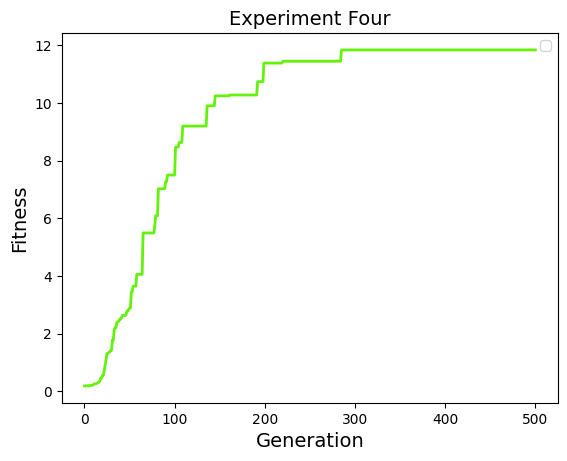

Figure(640x480)


In [15]:
print(ga_instance.plot_fitness(title="Experiment Four", linewidth=2))

Run best solution

In [24]:
solution, solution_fitness, solution_index = ga_instance.best_solution()
predictions = pygad.kerasga.predict(model=prototype_model, solution=solution,data=data_inputs)
mae = keras.losses.MeanAbsoluteError()
absolute_error = mae(data_outputs, predictions).numpy()
print("Solution fitness: ", solution_fitness, " (20 is the best)")
print("Predictions: ", predictions)
print("Absolute Error: ", absolute_error)

Solution fitness:  11.838399  (20 is the best)
Predictions:  [[110.10606 ]
 [111.95479 ]
 [112.687614]
 ...
 [ 80.86821 ]
 [125.371284]
 [ 76.92636 ]]
Absolute Error:  1.6894176


## About the code

The Genetic Algorithm code is based on the code shown in the docs of the PyGAD library.

The timeseries data code is based on the code shown in the chapter of the book Deep Learning with Python.

## References

1- PyGAD. pygad.kerasga Module. Website: https://pygad.readthedocs.io/en/latest/kerasga.html#